# Data-Mining-Roulette — how many random rules beat the market by luck? 🎰
### Spin a thousand random trading rules on pure noise — and watch the luckiest look like genius

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_luck_mimic_skill%3F: Confirmed](https://img.shields.io/badge/Does_luck_mimic_skill%3F-Confirmed-8b949e?style=flat-square)

Here is the most dangerous number in all of finance: the backtest score of the rule you decided to *keep*. This notebook builds a little p-hacking machine — it invents **1,000 random trading rules**, tests every one, and shows you the best. The twist: we run it on a tape we *built to contain no signal whatsoever*. If the best of 1,000 coin-flips still looks brilliant, then a brilliant backtest tells you nothing — until you ask the one question almost nobody asks.

> 📓 **This is the plain-language layer.** Want the HAC *t*-stats, the Bonferroni bar and White's Reality Check? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it, on a deterministic synthetic tape (the real-SPY numbers are frozen in [docs/results.md](../docs/results.md)). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from data_mining_roulette import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_tape():
    return data.load_real(fetch=False)

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| If I test 1,000 random rules on *pure noise*, how good is the best one? | **It looks great.** Best Sharpe ~**0.66**, *t*-stat ~**2.2** — a naive 'significant'. The *median* best-of-1,000 across seeds has a *t* of **2.68**. |
| How many of the 1,000 'beat the market' by chance? | **Dozens.** About **25** clear the famous *t* > 2 bar on a tape with *nothing in it* (it swings ~11–500 by luck). |
| So is a *t* > 2 backtest meaningless? | **On its own, yes.** The fix is to correct for how many rules you tried. Do that and **0 of 1000** survive — the mirage vanishes. |
| Does the machine actually work, or is it just blind? | **It works.** Plant a *real* edge and it finds it instantly and ranks it #1. The 'nothing' result is real, not a broken tool. |

> The luckiest of a thousand random rules will always look like skill. The only defence is to remember how many times you spun the wheel.

## 1 · The claim

Open any trading forum and you'll find a backtest with a Sharpe of 2 and a smooth equity curve, presented as proof. The strong version of the warning — from serious researchers — is darker than 'be careful':

> *With enough trials, a backtest Sharpe of 2 is **easy** to achieve on data that is pure noise.* — Bailey, Borwein, López de Prado & Zhu (2014)

In 1999, Sullivan, Timmermann & White ran **~7,800** technical trading rules on the Dow. The best looked wonderful. Under a test that accounts for the *search*, the magic evaporated. The claim we're testing is the uncomfortable one: **a great backtest is the expected outcome of trying many rules, even when none of them work.**

## 2 · So what?

If the best of many random rules looks real, then almost every 'discovered' strategy you see — yours included — is suspect. You stare at a chart, try a moving-average rule, it's mediocre; you try RSI, better; you tweak the threshold, *great*. You didn't find an edge — you ran a search and kept the luckiest result. The money you'd lose trading it is the *tuition* for not asking how many rules you tried. This is the single most common way retail and professional quants alike set fire to capital.

## 3 · How would we even know?

We build the p-hacking machine and aim it at a tape where we **know the truth**:

1. **The null tape.** A fake market that is pure random walk; every indicator we compute is noise, *uncorrelated with tomorrow*. There is, by construction, **no rule that beats the market except by luck**.
2. **1,000 random rules.** Each picks an indicator, a direction, and a threshold, then goes long tomorrow when the condition holds (else sits in cash). The roulette wheel.
3. **The honest question.** Not 'is the best rule good?' (it always is) but 'how good *should* the best of 1,000 look, when nothing is real?' — and does correcting for the search erase it?
4. **The positive control.** Re-run on a tape with a *planted* real edge. If the machine can't find a signal that's genuinely there, finding nothing on the null would prove nothing.

If the corrected test says 'this is just luck' on the null **and** 'this is real' on the planted-edge tape, the machine is trustworthy — and the lesson lands.

## 4 · The teardown — let's actually look

**First: spin the wheel on pure noise.** A tape with no signal at all. Here is the Sharpe ratio of all 1,000 random rules — and where the single best one lands.

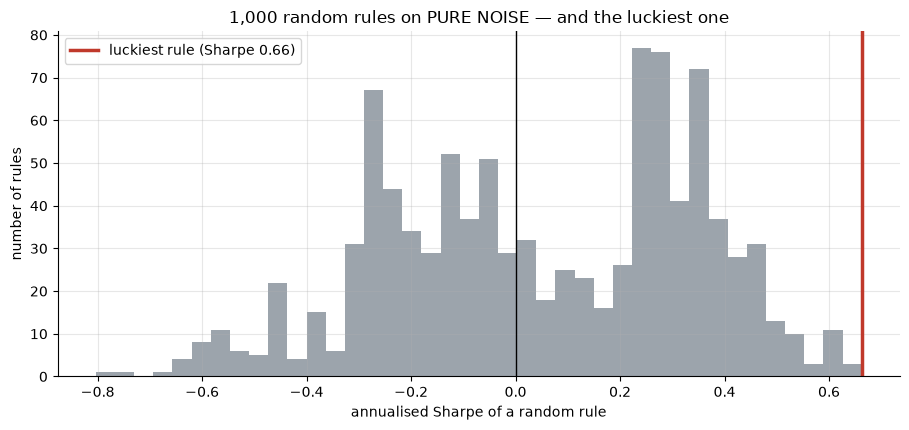

TAPE: synthetic null (nothing to find)
best rule: ma_gap_50 < q0.571  Sharpe=0.66  HAC t=2.20


In [2]:
# SYNTHETIC NULL TAPE — built to contain NO signal (planted_edge=0).
feats, fwd, truth = data.synthetic_tape(planted_edge=0.0, vol_cluster=0.0, seed=343)
res = st.run_experiment(feats, fwd, n_rules=1000, rc_boot=400, seed=343)
tbl = res['table']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(tbl['sharpe'].dropna(), bins=40, color=GREY, alpha=.85)
best = tbl['sharpe'].iloc[0]
ax.axvline(best, c=RED, lw=2.5, label=f'luckiest rule (Sharpe {best:.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('annualised Sharpe of a random rule'); ax.set_ylabel('number of rules')
ax.set_title('1,000 random rules on PURE NOISE — and the luckiest one')
ax.legend(); plt.tight_layout(); plt.show()
print('TAPE: synthetic null (nothing to find)')
print(f"best rule: {tbl['feature'].iloc[0]} {tbl['op'].iloc[0]} q{tbl['q'].iloc[0]}  "
      f"Sharpe={best:.2f}  HAC t={tbl['hac_t'].iloc[0]:.2f}")

On a tape with **nothing in it**, the luckiest of 1,000 rules posts a Sharpe of ~**0.66** and a *t*-stat of ~**2.2** — the textbook 'statistically significant' threshold. It is a slot machine that always pays out a winner; the winner is just whoever sat down at the luckiest seat.

**How many rules 'beat the market' on this empty tape?** Count the ones clearing the famous *t* > 2 bar — and compare to the bar you *should* use after trying 1,000.

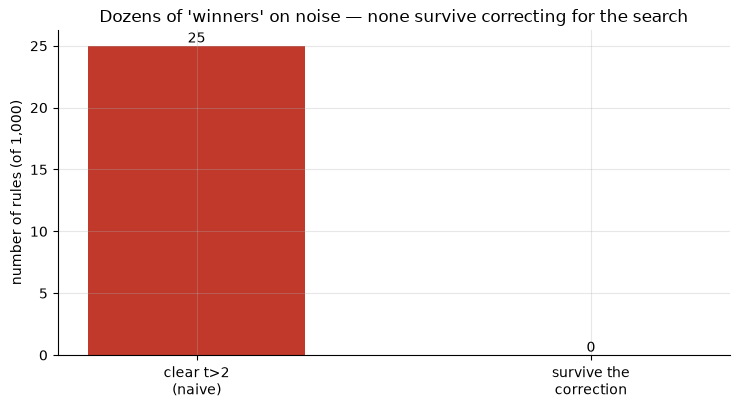

TAPE: synthetic null
rules clearing t>2 by chance: 25 of 1000  |  surviving Bonferroni: 0


In [3]:
# Still the SYNTHETIC NULL tape.
pc = res['pass_counts']
naive = pc['n_pass_naive']; bonf = pc['n_pass_bonferroni']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['clear t>2\n(naive)', 'survive the\ncorrection'], [naive, bonf],
       color=[RED, GREEN], width=.55)
ax.set_ylabel('number of rules (of 1,000)')
ax.set_title('Dozens of \'winners\' on noise — none survive correcting for the search')
for i, v in enumerate([naive, bonf]):
    ax.annotate(str(v), (i, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('TAPE: synthetic null')
print(f'rules clearing t>2 by chance: {naive} of 1000  |  surviving Bonferroni: {bonf}')

About **25** random rules 'beat the market' at *t* > 2 — on a tape where that is impossible by design. Once you demand the rule clear the bar appropriate for having tried 1,000 of them (Bonferroni), **0** survive. The dozens of winners were the wheel paying out, nothing more.

**Is the machine just blind to everything?** No — here's the proof. Plant a *real* edge in the tape and spin again. A trustworthy machine should find it and put it on top.

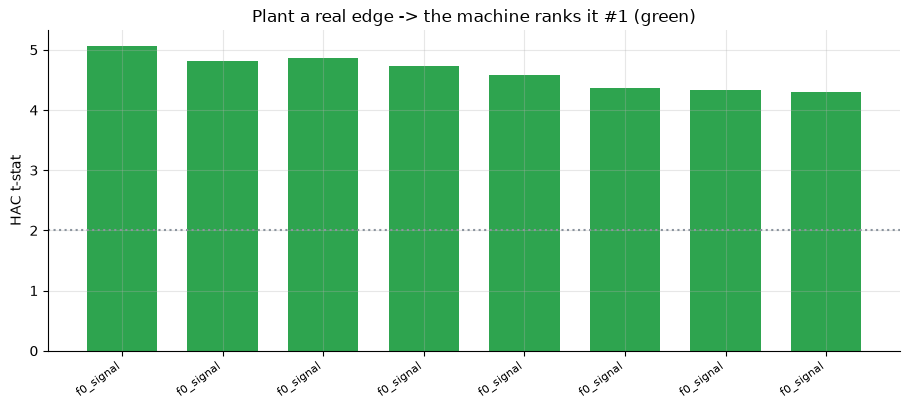

TAPE: synthetic positive control (planted edge on f0_signal)
top rule feature: f0_signal  (planted signal = f0_signal)


In [4]:
# SYNTHETIC POSITIVE CONTROL — a real edge planted on the 'f0_signal' feature.
fc, rc_, tc = data.synthetic_tape(planted_edge=0.10, vol_cluster=0.0, seed=343)
res_c = st.run_experiment(fc, rc_, n_rules=1000, rc_boot=400, seed=343)
top = res_c['table'].head(8)
colors = [GREEN if f == tc['signal_feature'] else GREY for f in top['feature']]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(range(len(top)), top['hac_t'], color=colors, width=.7)
ax.axhline(2, ls=':', c=GREY); ax.set_xticks(range(len(top)))
ax.set_xticklabels([f for f in top['feature']], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('HAC t-stat'); ax.set_title('Plant a real edge -> the machine ranks it #1 (green)')
plt.tight_layout(); plt.show()
print('TAPE: synthetic positive control (planted edge on f0_signal)')
print(f"top rule feature: {res_c['table']['feature'].iloc[0]}  "
      f"(planted signal = {tc['signal_feature']})")

The machine instantly puts the **planted-edge feature** (f0_signal) at #1, HAC *t* ~4.67, and 31 of its rules survive the correction. So when it says 'nothing' on the null, that means *nothing* — not a broken tool. The slot machine can tell a jackpot from a coincidence; the naive *t*-stat cannot.

## 5 · The verdict

- **Signal — None.** No rule mined from a 1,000-rule search is trustworthy on its own. The 'winners' are the maximum of a thousand noisy numbers, not a thousand discoveries.
- **Tradability — Mirage.** The search creates no edge to trade — only the illusion of one, which dies the moment you account for the search (or pay costs, or step out of sample).
- **Does luck mimic skill? — Confirmed.** On a provably-empty tape the best rule looks significant (2.2 *t*); correcting for the search (0 survivors, Reality-Check *p* = 0.3) reveals pure luck. The machine proves the point — and proves itself by nailing a planted edge.

## 6 · Could you actually trade it?

There is nothing to trade — that's the whole point. But it's worse than 'nothing': if you *did* deploy the luckiest backtest, you'd be trading a rule chosen precisely *because* it got lucky, so its future is, if anything, below average (the winner's curse). And the more rules you search, the more confident — and more wrong — you become. On the real tape we even found a rule that survives the correction (a faint, real mean-reversion effect), but it's a known, low-capacity micro-effect that fades with costs and out of sample — *not* something the roulette invented. The honest takeaway: a backtest is a hypothesis, not a result, until it has survived data it was never mined on.

## 7 · Going further 🚪

- **Turn up the search.** Re-run with `n_rules=5000` or add more features — watch the best naive *t* climb while the corrected verdict stays 'nothing'. The mirage grows with effort.
- **The single-rule cousin.** [Study 301 — Triple-RSI](../../301-triple-rsi/) dismantles one viral '90% win-rate' rule; this study is the *factory* that mints such rules from noise.
- **The other randomness.** [Study 350 — Dartboard-Portfolio](../../350-dartboard-portfolio/) randomises *which stocks* you hold; here we randomise the *rule*. Together: random holdings vs random logic.

*Got a backtest you love? Fork this, add your rule's feature to the roulette, and see how many random rules beat it by luck. If lots do, you didn't find an edge — you found a seat at the wheel.*